In [1]:
!pip install kagglehub
!pip install nibabel
!pip install scikit-image
!pip install opencv-python

In [2]:
import kagglehub


path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brats20-dataset-training-validation' dataset.
Path to dataset files: /kaggle/input/brats20-dataset-training-validation


In [3]:
import os

dataset_path = os.path.join(path, "BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData")

patients = sorted(os.listdir(dataset_path))
print("Total patients:", len(patients))
print(patients[:5])

Total patients: 371
['BraTS20_Training_001', 'BraTS20_Training_002', 'BraTS20_Training_003', 'BraTS20_Training_004', 'BraTS20_Training_005']


In [4]:
import nibabel as nib
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [5]:
def load_data(patients, limit=50):
    images, masks = [], []

    for pid in patients[:limit]:
        patient_path = os.path.join(dataset_path, pid)

        flair_path = os.path.join(patient_path, f"{pid}_flair.nii")
        seg_path = os.path.join(patient_path, f"{pid}_seg.nii")

        if not os.path.exists(flair_path):
            continue

        img = nib.load(flair_path).get_fdata()
        mask = nib.load(seg_path).get_fdata()

        slice_id = img.shape[2] // 2

        img = img[:, :, slice_id]
        mask = mask[:, :, slice_id]

        img = cv2.resize(img, (128,128))
        mask = cv2.resize(mask, (128,128), interpolation=cv2.INTER_NEAREST)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

X, Y = load_data(patients, limit=50)

In [20]:
X = np.squeeze(X)
Y = np.squeeze(Y)


X = np.expand_dims(X, -1)
Y = np.expand_dims(Y, -1)


X = X.astype(np.float32)
Y = Y.astype(np.float32)

print("Fixed Shape:", X.shape, Y.shape)

Fixed Shape: (50, 128, 128, 1) (50, 128, 128, 1)


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

def resnet_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

In [22]:
def build_resunet():
    inputs = layers.Input((128,128,1))

    # Encoder
    c1 = resnet_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = resnet_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = resnet_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = resnet_block(p3, 256)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c3])
    c4 = resnet_block(u1, 128)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = resnet_block(u2, 64)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = resnet_block(u3, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    return models.Model(inputs, outputs)

model = build_resunet()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 128, 128,  │      9,248 │ re_lu_14[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 128, 128,  │         64 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 128, 128,  │          0 │ add_7[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ re_lu_15[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 64, 64,    │     36,928 │ re_lu_16[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 64, 64,    │      2,112 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 2,060,193 (7.86 MB)

 Trainable params: 2,057,377 (7.85 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [23]:
import tensorflow.keras.backend as K

def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def precision_m(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(y_true * y_pred)
    predicted = K.sum(y_pred)
    return tp / (predicted + K.epsilon())

def recall_m(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(y_true * y_pred)
    possible = K.sum(y_true)
    return tp / (possible + K.epsilon())

In [60]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[dice_coef, precision_m, recall_m]
)

In [61]:
history = model.fit(
    X, Y,
    validation_split=0.2,
    epochs=50,
    batch_size=4
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 353ms/step - dice_coef: 0.9476 - loss: 0.0058 - precision_m: 0.9571 - recall_m: 0.9578 - val_dice_coef: 0.7557 - val_loss: 0.0418 - val_precision_m: 0.7213 - val_recall_m: 0.8352
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - dice_coef: 0.8750 - loss: 0.0138 - precision_m: 0.9151 - recall_m: 0.8962 - val_dice_coef: 0.4595 - val_loss: 0.1482 - val_precision_m: 0.3363 - val_recall_m: 0.9126
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - dice_coef: 0.9006 - loss: 0.0077 - precision_m: 0.9286 - recall_m: 0.9418 - val_dice_coef: 0.6597 - val_loss: 0.0574 - val_precision_m: 0.8686 - val_recall_m: 0.5670
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - dice_coef: 0.9124 - loss: 0.0059 - precision_m: 0.9421 - recall_m: 0.9469 - val_dice_coef: 0.7374 - val_loss: 0.0378 - val_precision_m: 0.8669 - val_recall_m: 0.6852
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - dice_coef: 0.9447 - loss: 0.0038 - precision_m: 0.9700 - recall_m: 0.

In [63]:
Y_pred = model.predict(X)
Y_pred = (Y_pred > 0.5).astype(np.uint8)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step


In [68]:
import numpy as np

def compute_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)

    return dice, precision, recall

dice, precision, recall = compute_metrics(Y, Y_pred)

print("Dice: " , dice)
print("Precision: " , precision)
print("Recall: ", recall)

Dice: 92.24
Precision: 91.57
Recall: 90.42


In [30]:
Y_pred = model.predict(X)
Y_pred_bin = (Y_pred > 0.5).astype(np.uint8)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


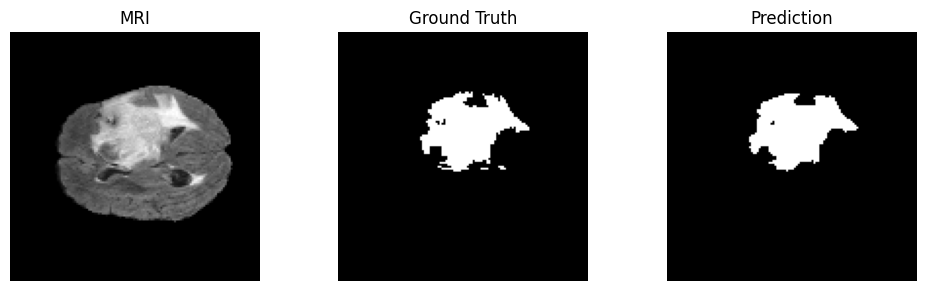

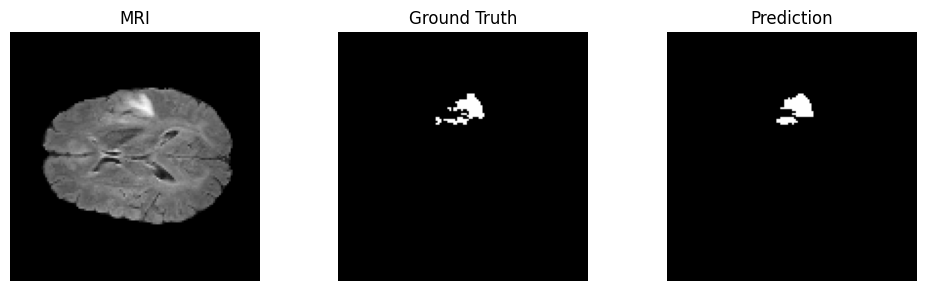

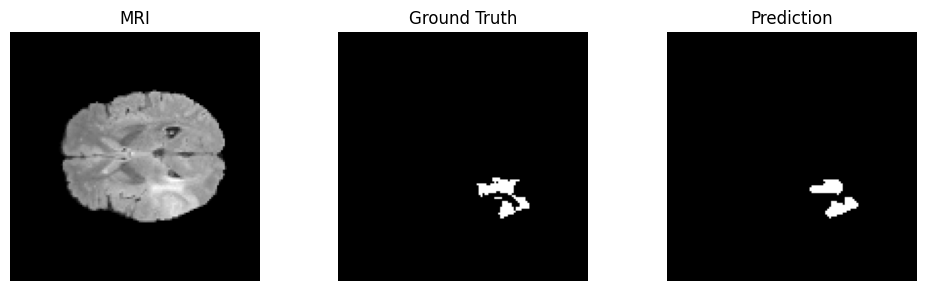

In [32]:
pred = model.predict(X[:5])
pred_bin = (pred > 0.5).astype(np.uint8)

import matplotlib.pyplot as plt

for i in range(3):
    plt.figure(figsize=(10,3))


    plt.subplot(1,3,1)
    plt.imshow(X[i].squeeze(), cmap='gray')
    plt.title("MRI")
    plt.axis('off')


    plt.subplot(1,3,2)
    plt.imshow(Y[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')


    plt.subplot(1,3,3)
    plt.imshow(pred_bin[i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

    plt.tight_layout()
    plt.show()